In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Reading the Evaluation data by Pathologist

In [54]:
evaluator_id = 'evaluator5'
eval_data_path = f"input/{evaluator_id}/pathopen_image_augmentation_eval_data.csv"
eval_data = pd.read_csv(eval_data_path)
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question_1,OE_Correct_Answer_1,Evaluation Image_Augmentation\n(Benchmark 4),Unnamed: 6,OE_Question_2,OE_Correct_Answer_2,Evaluation Image_Augmentation\n(Benchmark 4).1,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,Clinical Relevance,Visual Grounding,NaN,NaN,Clinical Relevance,Visual Grounding
1,27.0,img_pathopen_27_01_aug_1.png,https://drive.google.com/file/d/1wlSR_kyGexMPn...,The special structures depicted in this image ...,These are typical Verocay bodies depicted with...,2,2,What is the cell of origin of the lesion depic...,The accepted cell of origin for schwannomas ar...,2,2
2,84.0,img_pathopen_84_01_aug_2.png,https://drive.google.com/file/d/1gJOtUj9VlLXz-...,What is the primary normal cellular component ...,The primary normal cellular population is skel...,-1,0,How would you describe the abnormality in the ...,There is deposition of an abnormal extracellul...,-1,0
3,145.0,img_pathopen_145_02_aug_0.png,https://drive.google.com/file/d/1MjewyOyZXuDA7...,What is the most likely diagnosis for this bio...,The image shows a malignant infiltrate with cy...,2,2,What is the expected immunohistochemistry prof...,"The image shows a malignant infiltrate, which ...",2,2
4,134.0,img_pathopen_134_02_aug_0.png,https://drive.google.com/file/d/1QEwje9piMs3Zi...,What is the most appropriate description of th...,The portal regions in this image show dense ch...,2,2,"In this image from the liver of an adult male,...",The affected areas are the portal regions of t...,2,2


Creating the directory structure to save Graphs and Output for Each Evaluator

In [55]:
output_data_path = f"output/{evaluator_id}"
os.makedirs(output_data_path, exist_ok=True)

Renaming some columns

In [56]:
eval_data = eval_data.rename(columns={'Evaluation Image_Augmentation\n(Benchmark 4)': 'OE_Image_Augmentation_1_Clin_Relv',
                                        'Unnamed: 6': 'OE_Image_Augmentation_1_Vis_Ground',
                                        'Evaluation Image_Augmentation\n(Benchmark 4).1': 'OE_Image_Augmentation_2_Clin_Relv',
                                        'Unnamed: 10': 'OE_Image_Augmentation_2_Vis_Ground',
                                        })

eval_data = eval_data.drop(index=0) #dropping the first row which contains the benchmark names
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question_1,OE_Correct_Answer_1,OE_Image_Augmentation_1_Clin_Relv,OE_Image_Augmentation_1_Vis_Ground,OE_Question_2,OE_Correct_Answer_2,OE_Image_Augmentation_2_Clin_Relv,OE_Image_Augmentation_2_Vis_Ground
1,27.0,img_pathopen_27_01_aug_1.png,https://drive.google.com/file/d/1wlSR_kyGexMPn...,The special structures depicted in this image ...,These are typical Verocay bodies depicted with...,2,2,What is the cell of origin of the lesion depic...,The accepted cell of origin for schwannomas ar...,2,2
2,84.0,img_pathopen_84_01_aug_2.png,https://drive.google.com/file/d/1gJOtUj9VlLXz-...,What is the primary normal cellular component ...,The primary normal cellular population is skel...,-1,0,How would you describe the abnormality in the ...,There is deposition of an abnormal extracellul...,-1,0
3,145.0,img_pathopen_145_02_aug_0.png,https://drive.google.com/file/d/1MjewyOyZXuDA7...,What is the most likely diagnosis for this bio...,The image shows a malignant infiltrate with cy...,2,2,What is the expected immunohistochemistry prof...,"The image shows a malignant infiltrate, which ...",2,2
4,134.0,img_pathopen_134_02_aug_0.png,https://drive.google.com/file/d/1QEwje9piMs3Zi...,What is the most appropriate description of th...,The portal regions in this image show dense ch...,2,2,"In this image from the liver of an adult male,...",The affected areas are the portal regions of t...,2,2
5,142.0,img_pathopen_142_03_aug_1.png,https://drive.google.com/file/d/1bBcsvdjGCmhGn...,Based on the image depicting a section of the ...,The image shows typical changes of Graves dise...,0,0,What is the best histologic description of thi...,The image shows typical changes of Grave's dis...,0,0


Converting all the evaluation columns from Str to Int

In [57]:
eval_data = eval_data.astype({'OE_Image_Augmentation_1_Clin_Relv': 'float',
                                'OE_Image_Augmentation_1_Vis_Ground': 'float',
                                'OE_Image_Augmentation_2_Clin_Relv': 'float',
                                'OE_Image_Augmentation_2_Vis_Ground': 'float',
                                })

eval_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 1 to 38
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   CASE_ID                             38 non-null     float64
 1   Image_ID                            38 non-null     object 
 2   Image_URL                           38 non-null     object 
 3   OE_Question_1                       38 non-null     object 
 4   OE_Correct_Answer_1                 38 non-null     object 
 5   OE_Image_Augmentation_1_Clin_Relv   37 non-null     float64
 6   OE_Image_Augmentation_1_Vis_Ground  37 non-null     float64
 7   OE_Question_2                       37 non-null     object 
 8   OE_Correct_Answer_2                 37 non-null     object 
 9   OE_Image_Augmentation_2_Clin_Relv   37 non-null     float64
 10  OE_Image_Augmentation_2_Vis_Ground  37 non-null     float64
dtypes: float64(5), object(6)
memory usage: 3.4+ KB


Finding Missing Evaluations or Wrong Evaluations

In [58]:
OE_Correct_Answer_1_Clin_Relv_Missing = eval_data[(eval_data['OE_Question_1'].notnull()) & (eval_data['OE_Correct_Answer_1'].notnull()) & ((eval_data['OE_Image_Augmentation_1_Clin_Relv'].isnull()) | (~eval_data['OE_Image_Augmentation_1_Clin_Relv'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_1_Vis_Ground_Missing = eval_data[(eval_data['OE_Question_1'].notnull()) & (eval_data['OE_Correct_Answer_1'].notnull()) & ((eval_data['OE_Image_Augmentation_1_Vis_Ground'].isnull()) | (~eval_data['OE_Image_Augmentation_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Clin_Relv_Missing = eval_data[(eval_data['OE_Question_2'].notnull()) & (eval_data['OE_Correct_Answer_2'].notnull()) & ((eval_data['OE_Image_Augmentation_2_Clin_Relv'].isnull()) | (~eval_data['OE_Image_Augmentation_2_Clin_Relv'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Vis_Ground_Missing = eval_data[(eval_data['OE_Question_2'].notnull()) & (eval_data['OE_Correct_Answer_2'].notnull()) & ((eval_data['OE_Image_Augmentation_2_Vis_Ground'].isnull()) | (~eval_data['OE_Image_Augmentation_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()

print(f"OE_Correct_Answer_1_Clin_Relv_Missing: {OE_Correct_Answer_1_Clin_Relv_Missing}")
print(f"OE_Correct_Answer_1_Vis_Ground_Missing: {OE_Correct_Answer_1_Vis_Ground_Missing}")
print(f"OE_Correct_Answer_2_Clin_Relv_Missing: {OE_Correct_Answer_2_Clin_Relv_Missing}")
print(f"OE_Correct_Answer_2_Vis_Ground_Missing: {OE_Correct_Answer_2_Vis_Ground_Missing}")

OE_Correct_Answer_1_Clin_Relv_Missing: ['img_pathopen_25_01_aug_0.png']
OE_Correct_Answer_1_Vis_Ground_Missing: ['img_pathopen_25_01_aug_0.png']
OE_Correct_Answer_2_Clin_Relv_Missing: []
OE_Correct_Answer_2_Vis_Ground_Missing: []


#### Correct Answer

1

In [59]:
oe_correct_answer_1_clin_relv_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Image_Augmentation_1_Clin_Relv'].notnull()]
oe_correct_answer_1_clin_relv_total = len(oe_correct_answer_1_clin_relv_df)
oe_correct_answer_1_clin_relv_eval_2 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == 2])
oe_correct_answer_1_clin_relv_eval_1 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == 1])
oe_correct_answer_1_clin_relv_eval_0 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == 0])
oe_correct_answer_1_clin_relv_eval_neg_1 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == -1])

In [60]:
oe_correct_answer_1_vis_ground_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Image_Augmentation_1_Vis_Ground'].notnull()]
oe_correct_answer_1_vis_ground_total = len(oe_correct_answer_1_vis_ground_df)
oe_correct_answer_1_vis_ground_eval_2 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == 2])
oe_correct_answer_1_vis_ground_eval_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == 1])
oe_correct_answer_1_vis_ground_eval_0 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == 0])
oe_correct_answer_1_vis_ground_eval_neg_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == -1])


2

In [61]:
oe_correct_answer_2_clin_relv_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Image_Augmentation_2_Clin_Relv'].notnull()]
oe_correct_answer_2_clin_relv_total = len(oe_correct_answer_2_clin_relv_df)
oe_correct_answer_2_clin_relv_eval_2 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == 2])
oe_correct_answer_2_clin_relv_eval_1 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == 1])
oe_correct_answer_2_clin_relv_eval_0 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == 0])
oe_correct_answer_2_clin_relv_eval_neg_1 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == -1])

In [62]:
oe_correct_answer_2_vis_ground_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Image_Augmentation_2_Vis_Ground'].notnull()]
oe_correct_answer_2_vis_ground_total = len(oe_correct_answer_2_vis_ground_df)
oe_correct_answer_2_vis_ground_eval_2 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == 2])
oe_correct_answer_2_vis_ground_eval_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == 1])
oe_correct_answer_2_vis_ground_eval_0 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == 0])
oe_correct_answer_2_vis_ground_eval_neg_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == -1])

Calculating the consolidated information all the correct questions/answers

In [63]:
correct_answer_benchmark_label = [
                                    'Clinical Relevance',
                                    'Visual Grounding',
                                ]

correct_answer_total = [oe_correct_answer_1_clin_relv_total + oe_correct_answer_2_clin_relv_total,
                        oe_correct_answer_1_vis_ground_total + oe_correct_answer_2_vis_ground_total
                        ]

correct_answer_eval_2 = [oe_correct_answer_1_clin_relv_eval_2 + oe_correct_answer_2_clin_relv_eval_2,
                        oe_correct_answer_1_vis_ground_eval_2 + oe_correct_answer_2_vis_ground_eval_2,
                        ]

correct_answer_eval_1 = [oe_correct_answer_1_clin_relv_eval_1 + oe_correct_answer_2_clin_relv_eval_1,
                        oe_correct_answer_1_vis_ground_eval_1 + oe_correct_answer_2_vis_ground_eval_1,
                        ]

correct_answer_eval_0 = [oe_correct_answer_1_clin_relv_eval_0 + oe_correct_answer_2_clin_relv_eval_0,
                        oe_correct_answer_1_vis_ground_eval_0 + oe_correct_answer_2_vis_ground_eval_0
                        ]

correct_answer_eval_neg_1 = [oe_correct_answer_1_clin_relv_eval_neg_1 + oe_correct_answer_2_clin_relv_eval_neg_1,
                            oe_correct_answer_1_vis_ground_eval_neg_1 + oe_correct_answer_2_vis_ground_eval_neg_1
                            ]

correct_answer_eval_data = pd.DataFrame({'Total': correct_answer_total,
                                        'Level 2': correct_answer_eval_2,
                                        'Level 1': correct_answer_eval_1,
                                        'Level 0': correct_answer_eval_0,
                                        'Level -1': correct_answer_eval_neg_1}, index=[correct_answer_benchmark_label])

correct_answer_eval_data

,Total,Level 2,Level 1,Level 0,Level -1
Clinical Relevance,74,55,5,5,9
Visual Grounding,74,55,5,7,7


Save the Evaluation Data for correct answers

In [64]:
correct_answer_eval_data.to_pickle(os.path.join(output_data_path, 'pathopen_image_augmentation_correct_answer_eval_data.pkl'))

Open-Ended Image Augmentation Graph

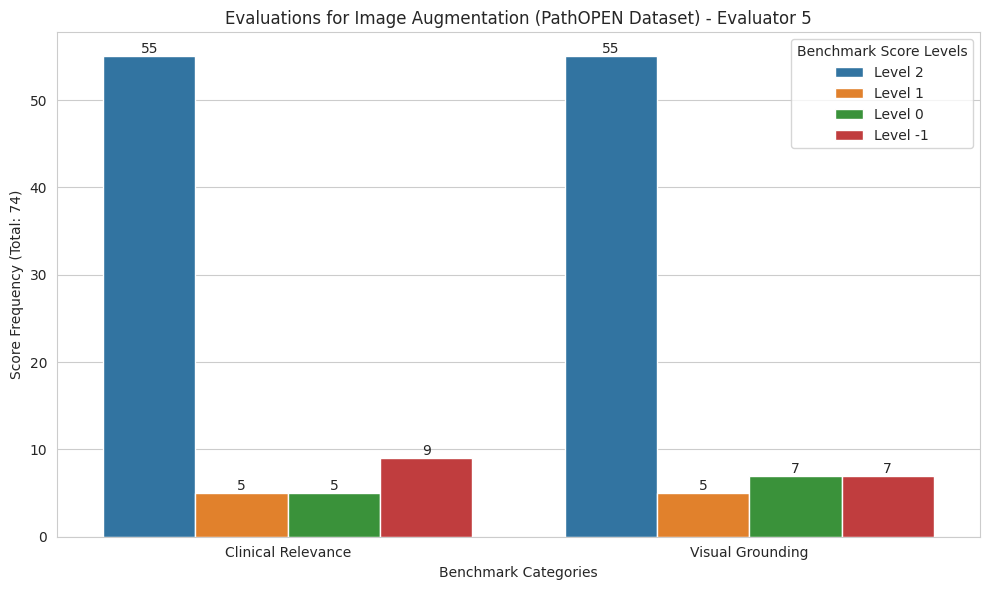

In [65]:
temp_data = correct_answer_eval_data.drop(columns=['Total']).reset_index().melt(id_vars='level_0', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='level_0', y='Values', hue='Column Names')

for container in ax.containers:
    ax.bar_label(container)
    
plt.title(f'Evaluations for Image Augmentation (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answer_total[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_image_augmentation.png')
plt.show()